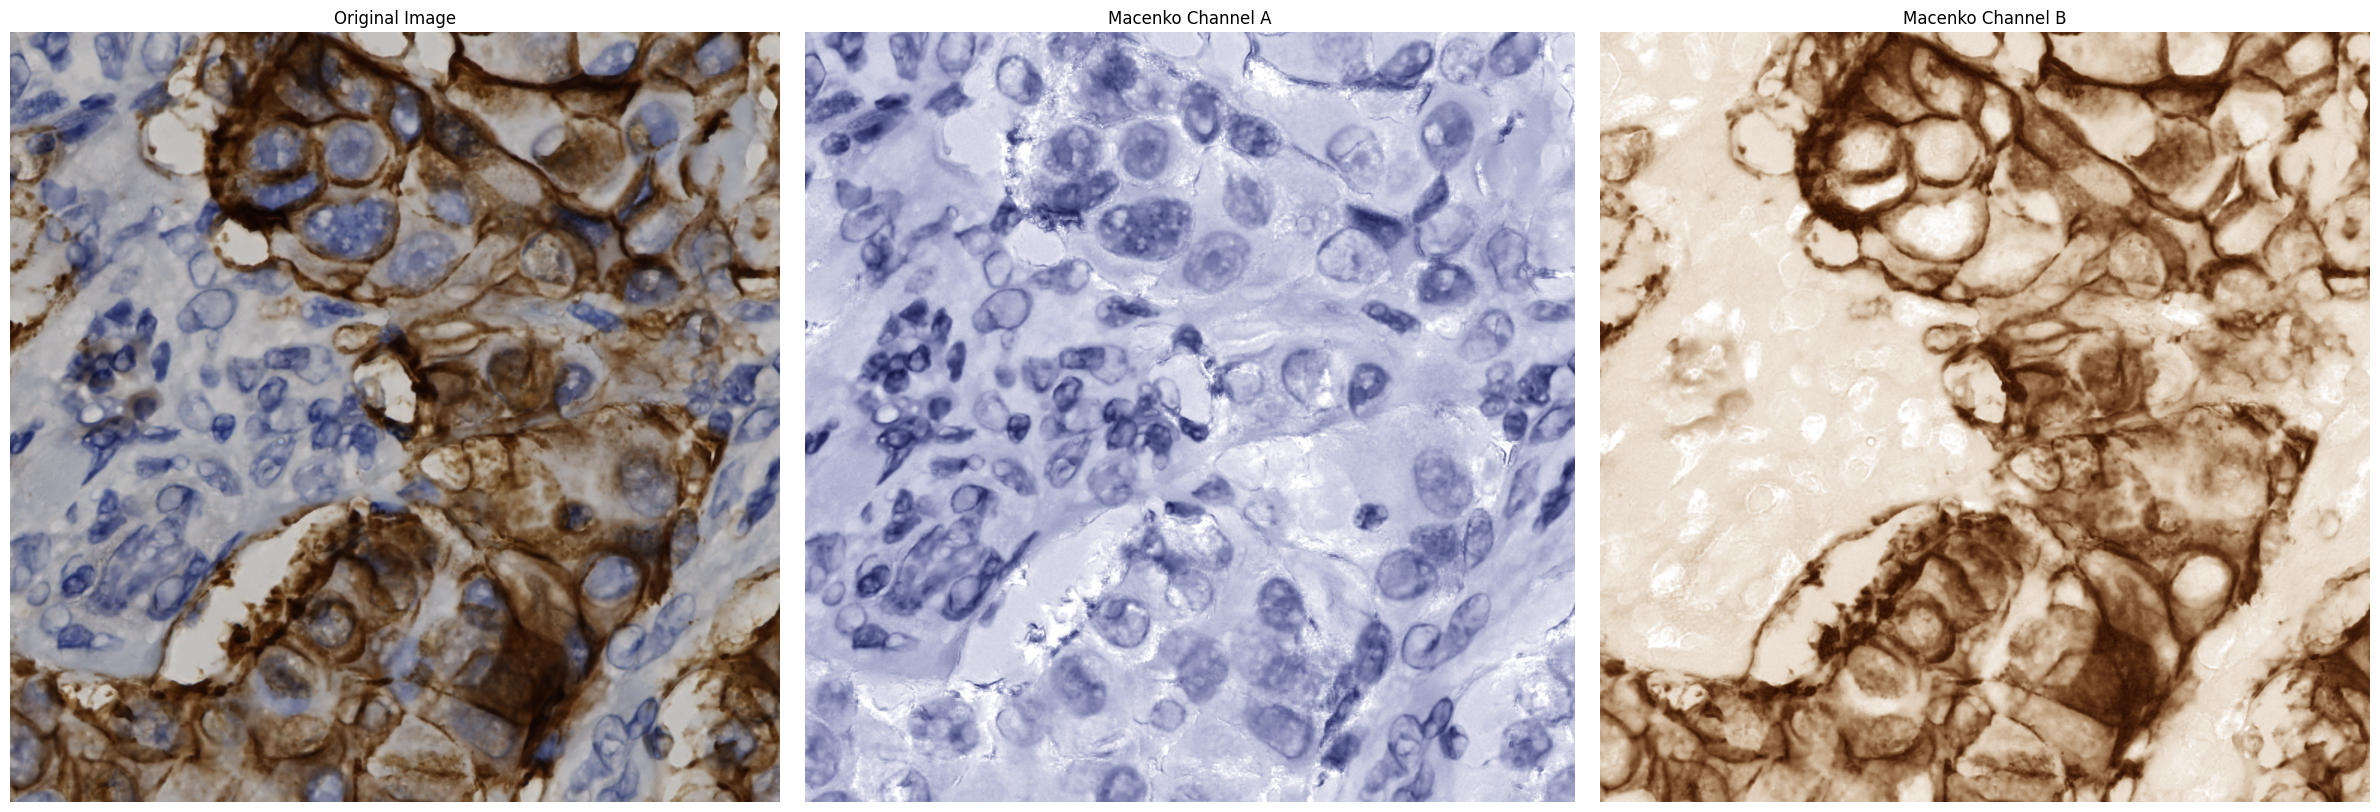

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 讀取影像
image_path = '/home/sec312/project/tsgh/cell_mask/hybrid/test_picture/her2/tile_x12288_y10240.tiff'
ihc_rgb = plt.imread(image_path)

# --- Macenko 染色分離 (完整流程) ---
def macenko_separate(img, Io=240, alpha=1, beta=0.15):
    """
    執行完整的 Macenko 染色分離流程。
    
    Returns:
        img_A   : Channel A 重建影像, shape (H, W, 3), float [0, 1]
        img_B   : Channel B 重建影像, shape (H, W, 3), float [0, 1]
        stain_matrix : 估計的染色矩陣, shape (2, 3)
    """
    H, W = img.shape[:2]

    # Step 1: 提取染色向量 (Macenko PCA)
    img_flat = img.reshape((-1, 3)).astype(float)
    OD = -np.log((img_flat + 1) / Io)
    OD_tissue = OD[~np.any(OD < beta, axis=1)]

    eigvals, eigvecs = np.linalg.eigh(np.cov(OD_tissue.T))
    eigvecs = eigvecs[:, [1, 2]]   # 取前兩個主要特徵方向

    T_hat = np.dot(OD_tissue, eigvecs)
    phi = np.arctan2(T_hat[:, 1], T_hat[:, 0])
    minPhi = np.percentile(phi, alpha)
    maxPhi = np.percentile(phi, 100 - alpha)

    vMin = np.dot(eigvecs, np.array([np.cos(minPhi), np.sin(minPhi)]))
    vMax = np.dot(eigvecs, np.array([np.cos(maxPhi), np.sin(maxPhi)]))

    stain_matrix = np.array([vMin, vMax])
    stain_matrix = stain_matrix / np.linalg.norm(stain_matrix, axis=1)[:, None]

    # Step 2: 計算每個像素的染劑濃度
    img_float = img.astype(np.float64) / 255.0
    OD_flat = -np.log(img_float.reshape(-1, 3) + 1e-6)
    concentrations = np.dot(OD_flat, np.linalg.pinv(stain_matrix))
    concentrations = np.clip(concentrations, 0, None).reshape(H, W, 2)

    # Step 3: 重建各通道影像
    def _reconstruct(conc_2d, stain_vec):
        channel_OD = np.outer(conc_2d.ravel(), stain_vec)
        return np.clip(np.exp(-channel_OD).reshape(H, W, 3), 0, 1)

    img_A = _reconstruct(concentrations[:, :, 0], stain_matrix[0])
    img_B = _reconstruct(concentrations[:, :, 1], stain_matrix[1])

    return img_A, img_B, stain_matrix

# 2. 執行分離
img_A, img_B, stain_matrix = macenko_separate(ihc_rgb)

# 3. 顯示結果
fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharex=True, sharey=True)
axes[0].imshow(ihc_rgb)
axes[0].set_title("Original Image")
axes[1].imshow(img_A)
axes[1].set_title("Macenko Channel A")
axes[2].imshow(img_B)
axes[2].set_title("Macenko Channel B")

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()


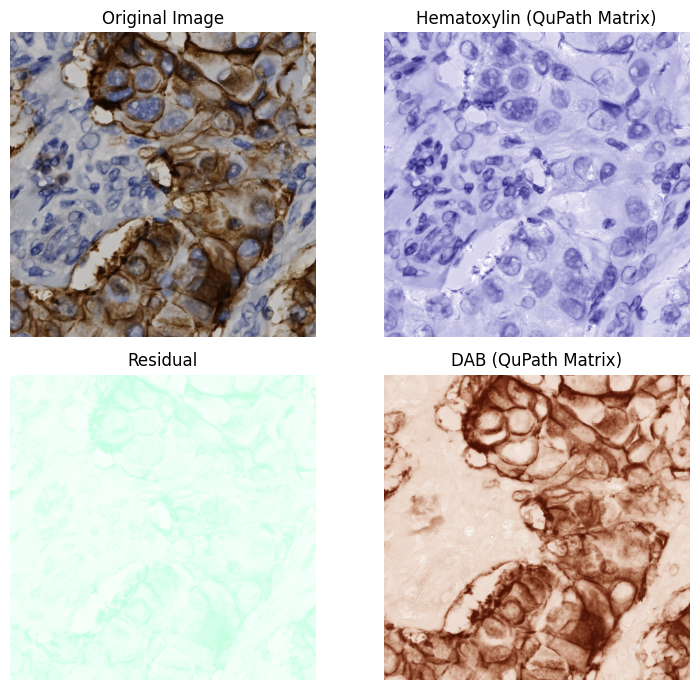

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import separate_stains, combine_stains

# 1. 讀取 IHC 影像 (RGB)
image_path = '/home/sec312/project/tsgh/cell_mask/hybrid/test_picture/her2/tile_x12288_y10240.tiff'
ihc_rgb = plt.imread(image_path)

# 2. 建立從 QuPath 取得的自訂染色矩陣
# 每一列 (row) 代表一種染劑在 RGB 光學密度空間的吸收向量
rgb_from_custom = np.array([
    [0.651,  0.701,  0.290],  # Stain 1: Hematoxylin
    [0.269,  0.568,  0.778],  # Stain 2: DAB
    [0.633, -0.713,  0.302]   # Stain 3: Residual
])

# 計算反矩陣，這是 separate_stains 需要用來將 RGB 轉換為染色濃度 (Concentration) 的矩陣
custom_from_rgb = np.linalg.inv(rgb_from_custom)

# 3. 執行顏色解捲積 (Color Deconvolution)
ihc_custom = separate_stains(ihc_rgb, custom_from_rgb)

# 4. 準備全零矩陣，用來單獨隔離並視覺化特定通道
null = np.zeros_like(ihc_custom[:, :, 0])

# 5. 重建各個單一染色的 RGB 影像
ihc_h = combine_stains(np.stack((ihc_custom[:, :, 0], null, null), axis=-1), rgb_from_custom)
ihc_d = combine_stains(np.stack((null, ihc_custom[:, :, 1], null), axis=-1), rgb_from_custom)
ihc_x = combine_stains(np.stack((null, null, ihc_custom[:, :, 2]), axis=-1), rgb_from_custom)

# 6. 顯示結果
fig, axes = plt.subplots(2, 2, figsize=(8, 7), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(ihc_rgb)
ax[0].set_title("Original Image")

ax[1].imshow(ihc_h)
ax[1].set_title("Hematoxylin (QuPath Matrix)")

ax[2].imshow(ihc_x)
ax[2].set_title("Residual")

ax[3].imshow(ihc_d)
ax[3].set_title("DAB (QuPath Matrix)")

for a in ax.ravel():
    a.axis('off')

fig.tight_layout()
plt.show()

In [3]:
import segmentation_models_pytorch as smp
print(smp.__version__)

0.5.1.dev0


/home/sec312/project/tsgh/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


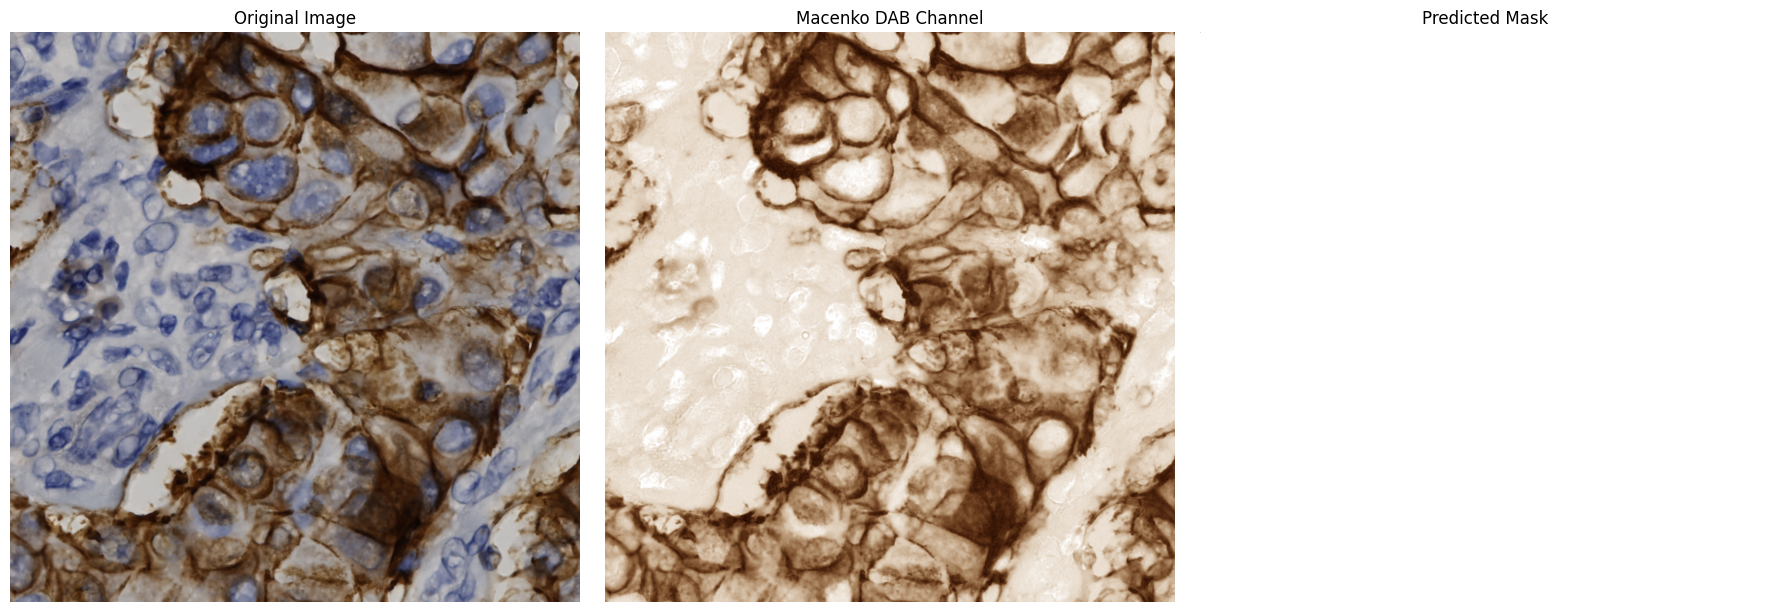

In [4]:
# inference Unet++ model
import segmentation_models_pytorch as smp
import torch

# load the best model from the path
model_path = '/home/sec312/project/tsgh/cell_mask/hybrid/models/best_model_unet.pth'
model = smp.UnetPlusPlus(
    encoder_name='efficientnet-b4',
    encoder_weights=None,
    in_channels=3,
    classes=2,
)
model.load_state_dict(torch.load(model_path))
model.eval()

image_path = '/home/sec312/project/tsgh/cell_mask/hybrid/test_picture/her2/tile_x12288_y10240.tiff'
image = plt.imread(image_path)

# 預處理：用 Macenko 分離取得 DAB 通道 (img_B), shape (H, W, 3), float [0, 1]
_, img_dab, _ = macenko_separate(image)

# 轉換為 PyTorch 張量 (C, H, W) 並添加批次維度
input_tensor = torch.from_numpy(img_dab).float().permute(2, 0, 1).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)

pred_mask = torch.argmax(output, dim=1).squeeze().cpu().numpy()

# 顯示結果
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)
axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[1].imshow(img_dab)
axes[1].set_title("Macenko DAB Channel")
axes[2].imshow(pred_mask, cmap='gray')
axes[2].set_title("Predicted Mask")
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()
